# Guide to pyhtp.xrd

Version: 0.0.1

The module is under active development and the API is subject to change.

In [1]:
import sys
import os
# Add the current directory that contains the current demo file to the path.
sys.path.append(os.path.dirname(os.getcwd()))
import pyhtp
# pylint: disable=report-missing-imports
import numpy as np

## XrdProcess
1. Initialize the class with the data and the parameters.

In [2]:
# A instance of the class can be created by:
model = pyhtp.xrd.XrdProcess(
    file_path=['test/test_xy/22-analyze/22-000-0000_exported.xy',
               'test/test_xy/46-analyze/46-000-0000_exported.xy',]
)
# Or by:
demo_twotheta = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
demo_intensity = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80, 90])
model = pyhtp.xrd.XrdProcess(
    two_theta=demo_twotheta,
    intensity=demo_intensity
)
# The path to reference data can be set by:
model = pyhtp.xrd.XrdProcess(
    file_path=['test/test_xy/22-analyze/22-000-0000_exported.xy',
               'test/test_xy/46-analyze/46-000-0000_exported.xy'],
    pattern_path='test/test_cif/pattern.pkl',
    structure_path='test/test_cif/structure.pkl'
)
# If pkl files don't exist, you can generate it by:
database = pyhtp.xrd.XrdDatabase(file_dir='test/test_cif/')
database.process()
# Properties can be set after initialization:
model = pyhtp.xrd.XrdProcess()
model.set_data(file_path=['test/test_xy/22-analyze/22-000-0000_exported.xy',
                          'test/test_xy/46-analyze/46-000-0000_exported.xy'])
model.set_database_path(
    pattern_path='test/test_cif/pattern.pkl',
    structure_path='test/test_cif/structure.pkl'
)

2. Process the intensity

In [3]:
# The baseline of the data can be substracted by:
model_temp = model.substract_baseline(lam=200)
# The data can be smoothed by:
model_temp = model_temp.smooth(window=101, factor=0.5)
# Or they can be combined together:
model = model.substract_baseline(lam=200).smooth(window=101, factor=0.5)
# If you want to copy a instance of XrdProcess, you should use:
model = model.copy()
# If use model_copy = model, the two instances will share the same memory, which is not what you want.

In [4]:
# To get peaks from the data, you can use:
peaks_value, peaks_index, properties = model.peaks(
    mask=[[33,35.5]],
    mask_height=0.1,
    height=0.06
)
print(peaks_value, peaks_index, properties)

[30.7299996  32.04999957 44.99499947] [4146 4410 6999] {'peak_heights': array([0.32074806, 0.11760942, 0.06091573])}


In [5]:
# To get the baseline of the data, you can use:
baseline = model.get_baseline(lam=200)
print(baseline)

[0.00168809 0.00170363 0.00171916 ... 0.00206197 0.00206929 0.00207661]


3. Visulization

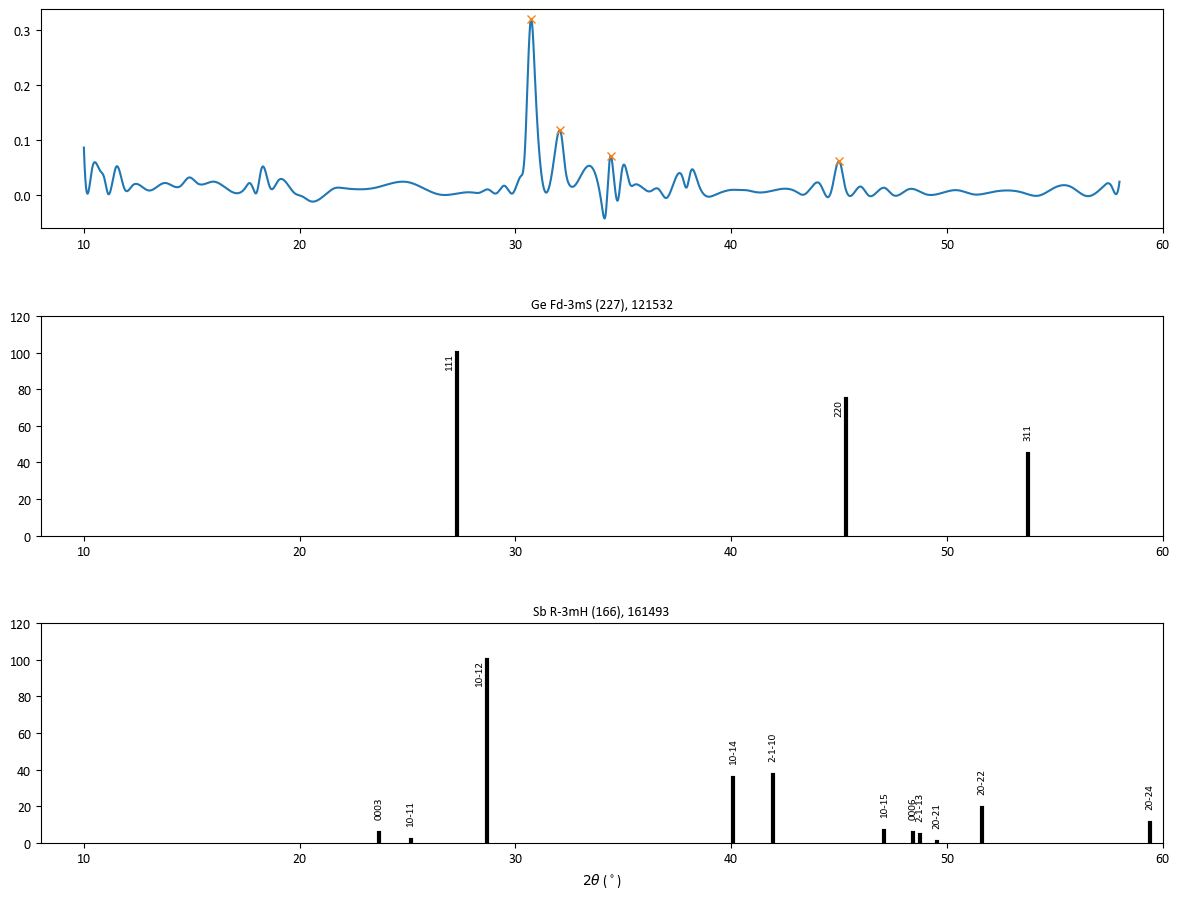

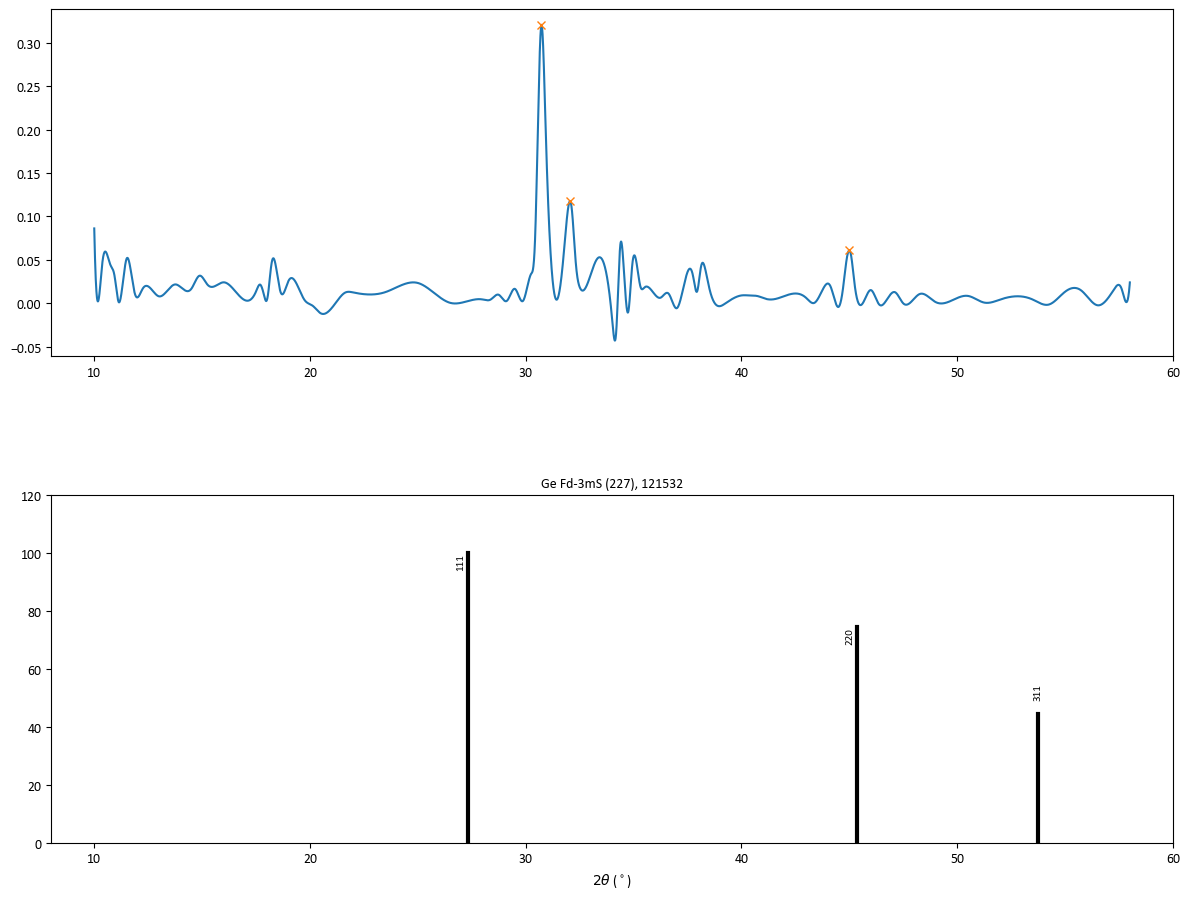

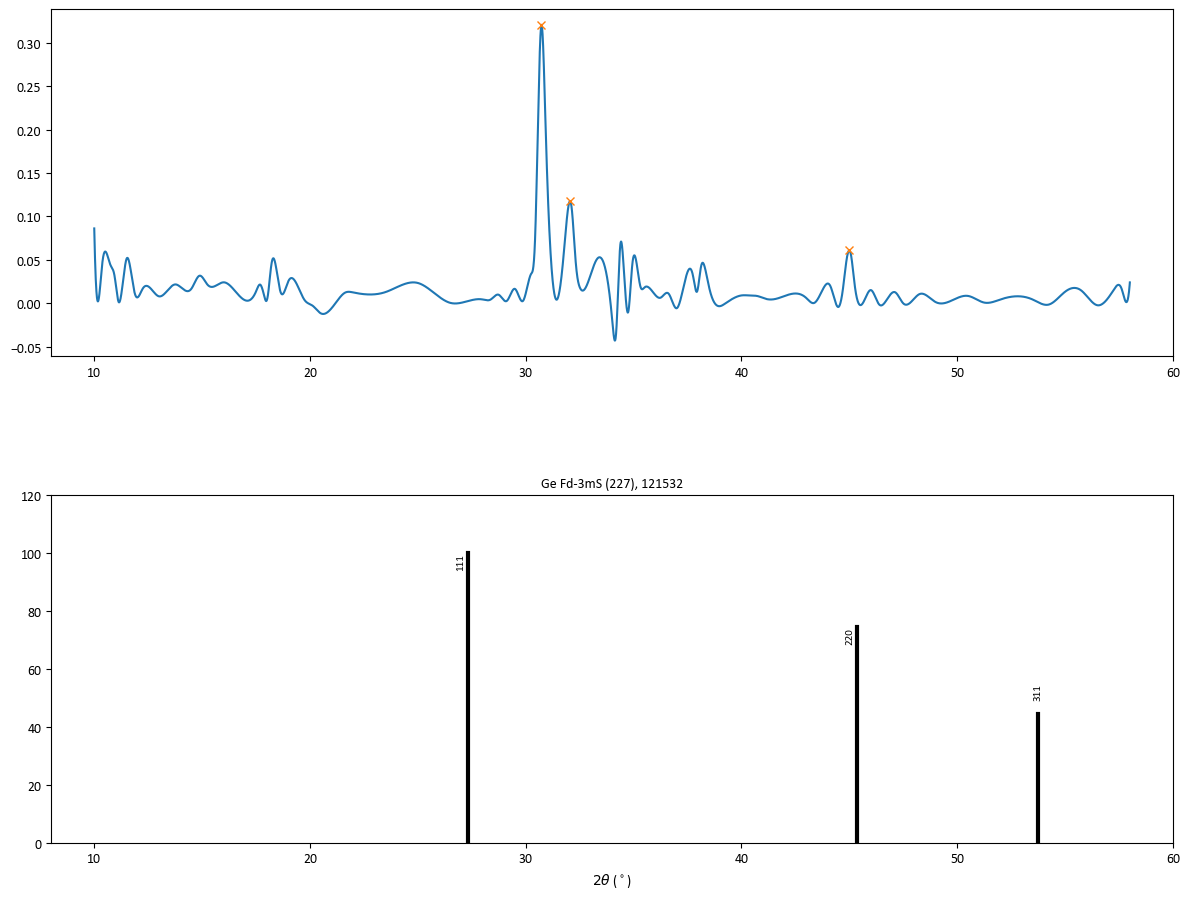

In [6]:
# A figure to compare current data with reference cards can be plotted by:
model.identify(if_process=False)
# The figure can be saved by:
model.identify(save_path='test/test_xy/exported_identify.png', if_show=False, if_process=False)
# You can set mask to prevent detecting some peaks by:
model.identify(
    mask=[[33,35.5]],
    mask_height=0.1,
    height=0.06,
    display_number=1,
    if_process=False
)
# identify() has integrated process function:
model = pyhtp.xrd.XrdProcess(
    file_path=['test/test_xy/22-analyze/22-000-0000_exported.xy',
               'test/test_xy/46-analyze/46-000-0000_exported.xy'],
    pattern_path='test/test_cif/pattern.pkl',
    structure_path='test/test_cif/structure.pkl'
)
model.identify(
    mask=[[33,35.5]],
    mask_height=0.1,
    height=0.06,
    display_number=1
)

## XrdDatabase

In [7]:
db = pyhtp.xrd.XrdDatabase(file_dir='test/test_cif/')
pattern_database, structure_database = db.process(if_save=True)
print(pattern_database, structure_database)
# The database can be saved by:
# db.process(if_save=True)
# You can set save_path to save the database to a specific path.
# db = pyhtp.xrd.XrdDatabase(file_dir='test/test_cif/', save_dir='test/test_cif/')
pattern_database = db.get_pattern()
print(pattern_database)

[{'name': 'Ge_CollCode121532.cif', 'two_theta': array([27.30403002, 45.34040643, 53.73802218, 66.0595768 , 72.88014767,
       83.76078472]), 'intensity': array([100.        ,  74.56057694,  44.62956794,  11.80571198,
        17.62143476,  24.32572693]), 'space_group': 'Fd-3mS', 'space_group_number': '227', 'formula': 'Ge', 'lattice_abc': ['5.65735(8)', '5.65735(8)', '5.65735(8)'], 'lattice_angles': ['90.', '90.', '90.'], 'icsd_code': '121532'}, {'name': 'Sb_CollCode161493.cif', 'two_theta': array([23.67252796, 25.14643018, 28.6963821 , 40.09448157, 41.95051115,
       47.09078715, 48.43870878, 48.73232486, 49.53772379, 51.6181867 ,
       59.42232847, 62.84156711, 64.87711092, 65.97448914, 66.87927811,
       68.61570921, 71.56604934, 75.37873819, 75.95423056, 76.63418196,
       78.452804  , 80.31195762, 81.54557145, 86.56399026]), 'intensity': array([  5.23560111,   1.54532858, 100.        ,  35.36928449,
        37.00413316,   6.39855954,   5.36092291,   4.40267935,
         0.2395

## XrdPlotter

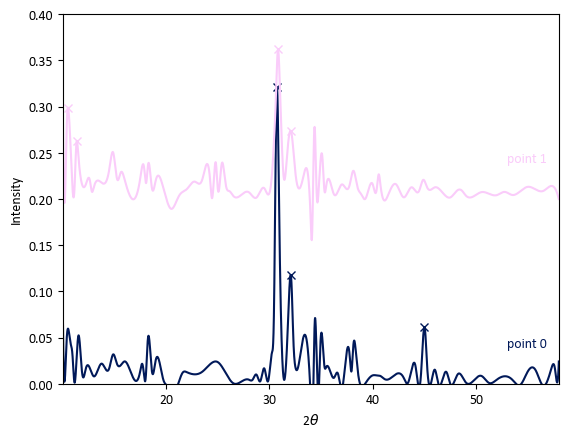

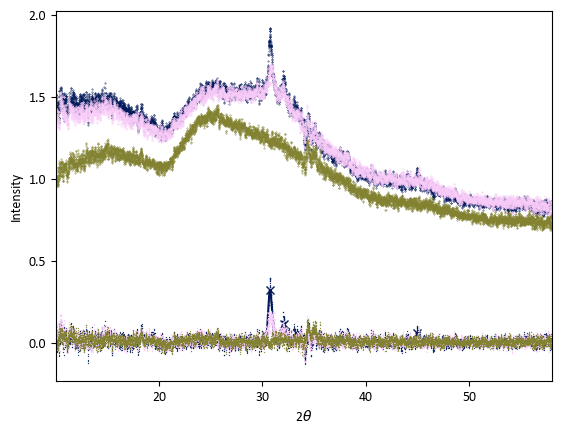

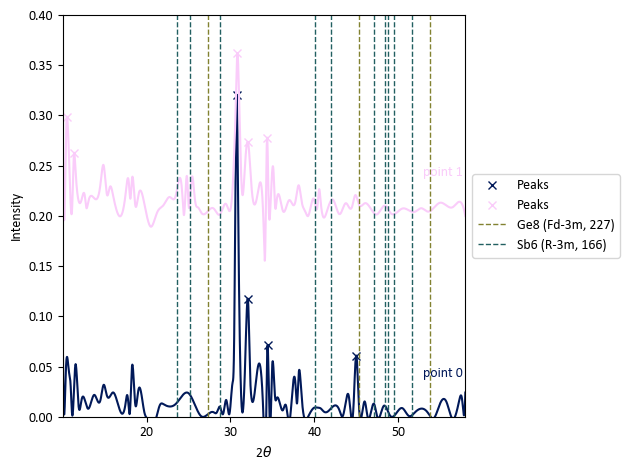

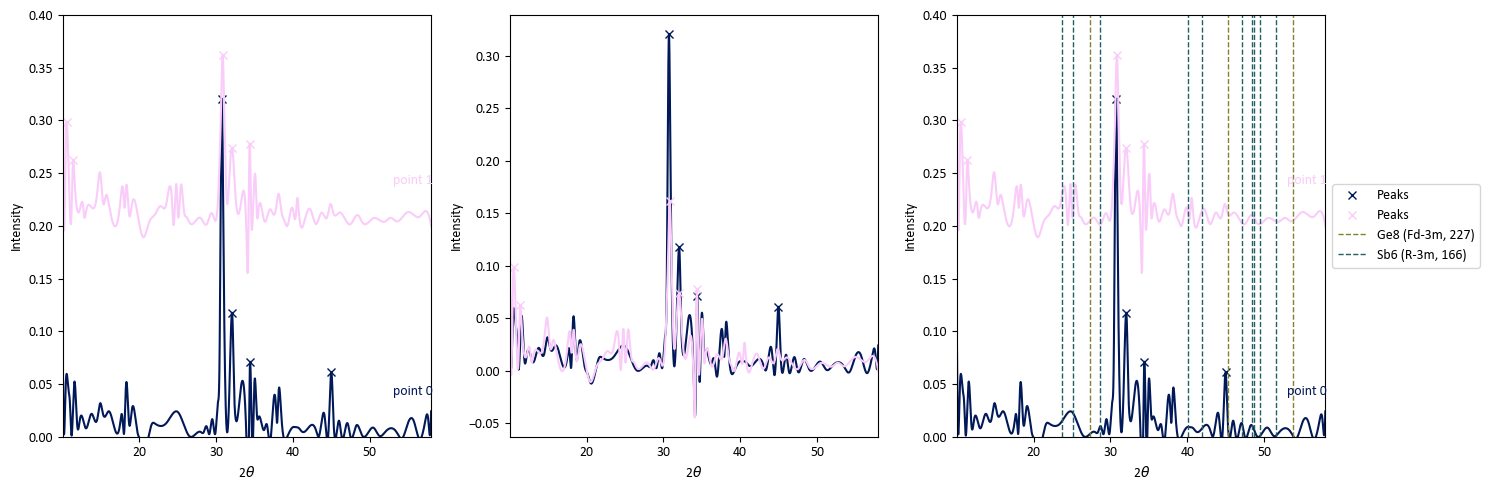

In [10]:
plotter = pyhtp.xrd.XrdPlotter(file_dir=['test/test_xy/22-analyze/',
                                     'test/test_xy/46-analyze/'])
plotter.plot_spectrum(
    index_to_plot=[0, 1],
    plot_peaks=True,
    plot_type='stack',
    mask=[[33,35.5]],
    mask_height=0.15,
    height=0.06,
    if_show=True,
    if_save=False,
    v_margin=0.2,
    dpi=300
)
plotter.plot_spectrum(
    index_to_plot=None, # If index_to_plot is None, all the data will be plotted.
    plot_peaks=True,
    plot_raw=True,
    plot_unsmoothed=True,
    plot_type='combine',
    mask=[[33,35.5]],
    mask_height=0.15,
    height=0.06,
    if_show=True,
    if_save=False,
    dpi=300
)
plotter.plot_spectrum_with_ref(
    pattern=None, # If pattern is None, the pattern from the database will be used.
    database_dir='test/test_cif/',
    index_to_plot=[0, 1], # All the arguments for plot_spectrum() can be used here.
    if_save=False,
    plot_type='stack'
)
# You can pass ax manually:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0] = plotter.plot_spectrum(ax=ax[0], index_to_plot=[0, 1], plot_type='stack', if_show=False)
ax[1] = plotter.plot_spectrum(ax=ax[1], index_to_plot=[0, 1], plot_type='combine', if_show=False)
ax[2] = plotter.plot_spectrum_with_ref(ax=ax[2], index_to_plot=[0, 1], plot_type='stack', if_show=False, database_dir='test/test_cif/')
plt.show()
# You can save the figure by:
# fig.savefig('test/test_xy/combined.png', dpi=300)